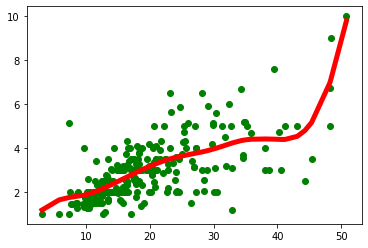

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def localWeight(point, X, ymat, k):
    m, n = X.shape
    weights = np.mat(np.eye(m))
    for i in range(m):
        diff = point - X[i]
        weights[i,i] = np.exp( (diff*diff.T)/(-2.0*k**2) ) # e power (dd' / -2k^2)
    W = (X.T * (weights*X)).I * (X.T * (weights*ymat.T)) # (X'(wX)).I * X'(w.ymat')
    return W

def localWeightReg(X, ymat, k):
    m,n = X.shape
    ypred = np.zeros(m)
    for i in range(m):
        ypred[i] = X[i] * localWeight(X[i], X, ymat, k)
    return ypred

def plott(X,pred,x,y):
    sortedArray = X[:,1].argsort(0)
    xsort = X[sortedArray][:,0][:,1]
    ysort = pred[sortedArray]
    plt.scatter(x,y,c="green")
    plt.plot(xsort, ysort,c="red", linewidth=5)
    plt.show()

if __name__ == "__main__":
    data = pd.read_csv("../datasets/data10_tips.csv")
    x = data["total_bill"]
    y = data["tip"]
    xmat = np.mat(x)
    ymat = np.mat(y)
    size = xmat.shape[1]
    ones = np.mat(np.ones(size))
    X = np.hstack((ones.T,xmat.T))
    pred = localWeightReg(X, ymat, 3)
    plott(X, pred, x, y)